# Gradient Boosting Model for Cryptocurrency Price Prediction

This notebook focuses on training a Gradient Boosting regression model for cryptocurrency price prediction:

1. Load the prepared data
2. Train a Gradient Boosting regression model
3. Evaluate model performance
4. Save the model for later use

Gradient Boosting is a powerful ensemble technique that builds trees sequentially, with each tree correcting the errors of its predecessors. It's known for its high accuracy and effectiveness with tabular data.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score, median_absolute_error

# Set random seed for reproducibility
np.random.seed(42)

# Check if models directory exists
os.makedirs('../models', exist_ok=True)

In [2]:
# Load the train-test split data
with open('../models/train_test_split.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
dates_train = data['dates_train']
dates_test = data['dates_test']

# Load feature list
with open('../models/features.pkl', 'rb') as f:
    features = pickle.load(f)

print(f"Loaded training data with {len(X_train)} samples and {X_train.shape[1]} features")
print(f"Loaded testing data with {len(X_test)} samples")
print(f"Features: {features}")

Loaded training data with 659668 samples and 13 features
Loaded testing data with 164918 samples
Features: ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']


In [6]:
# Function to evaluate regression models
def evaluate_regression_model(y_true, y_pred):
    """
    Calculate common regression metrics for model evaluation.
    
    Parameters:
        y_true: True target values
        y_pred: Predicted target values
        
    Returns:
        Dictionary of evaluation metrics
    """
    # Ensure arrays have the same length
    if len(y_true) != len(y_pred):
        min_length = min(len(y_true), len(y_pred))
        y_true = y_true[:min_length]
        y_pred = y_pred[:min_length]
        print(f"Warning: Arrays had different lengths. Truncated to {min_length} elements.")
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    
    # Calculate MAPE with handling for zeros
    epsilon = 1e-10
    y_true_safe = np.maximum(np.abs(y_true), epsilon)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    # Calculate directional accuracy (how often the direction of change is correct)
    # Convert to numpy arrays to ensure consistent indexing behavior
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    # Calculate directions
    actual_direction = np.sign(y_true_np[1:] - y_true_np[:-1])
    pred_direction = np.sign(y_pred_np[1:] - y_pred_np[:-1])
    
    # Ensure lengths match for comparison (they should, but just to be safe)
    min_dir_length = min(len(actual_direction), len(pred_direction))
    directional_accuracy = np.mean(actual_direction[:min_dir_length] == pred_direction[:min_dir_length]) * 100
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_var,
        'Median AE': median_ae,
        'Directional Accuracy (%)': directional_accuracy
    }

## Gradient Boosting Model Training

We'll train a Gradient Boosting regression model with optimized hyperparameters for cryptocurrency price prediction.

In [7]:
# Set Gradient Boosting parameters
params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'subsample': 0.8,
    'random_state': 42
}

# Initialize and train Gradient Boosting model
print("Training Gradient Boosting model...")
gb_model = GradientBoostingRegressor(**params)
gb_model.fit(X_train, y_train)

print("Training completed!")

Training Gradient Boosting model...
Training completed!
Training completed!


In [8]:
# Make predictions
train_preds = gb_model.predict(X_train)
test_preds = gb_model.predict(X_test)

# Evaluate model performance
train_metrics = evaluate_regression_model(y_train, train_preds)
test_metrics = evaluate_regression_model(y_test, test_preds)

# Print metrics
print("\nTraining set metrics:")
for metric, value in train_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")

print("\nTest set metrics:")
for metric, value in test_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")


Training set metrics:
  MAE: $792.0422
  RMSE: $14595.6472
  R²: 0.0495
  MAPE (%): 2219489370.46%
  Explained Variance: 0.0495
  Median AE: $364.4148
  Directional Accuracy (%): 39.01%

Test set metrics:
  MAE: $479.8929
  RMSE: $4314.4594
  R²: -0.0135
  MAPE (%): 584726691.43%
  Explained Variance: -0.0114
  Median AE: $295.2781
  Directional Accuracy (%): 41.14%


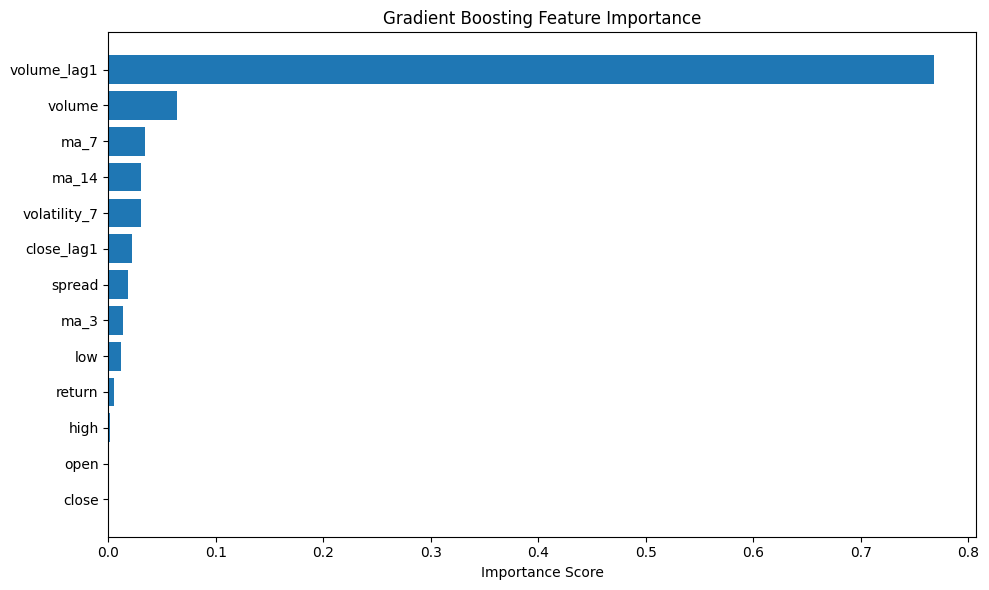

In [9]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
feature_importance = gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.barh(np.array(features)[sorted_idx], feature_importance[sorted_idx])
plt.title('Gradient Boosting Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

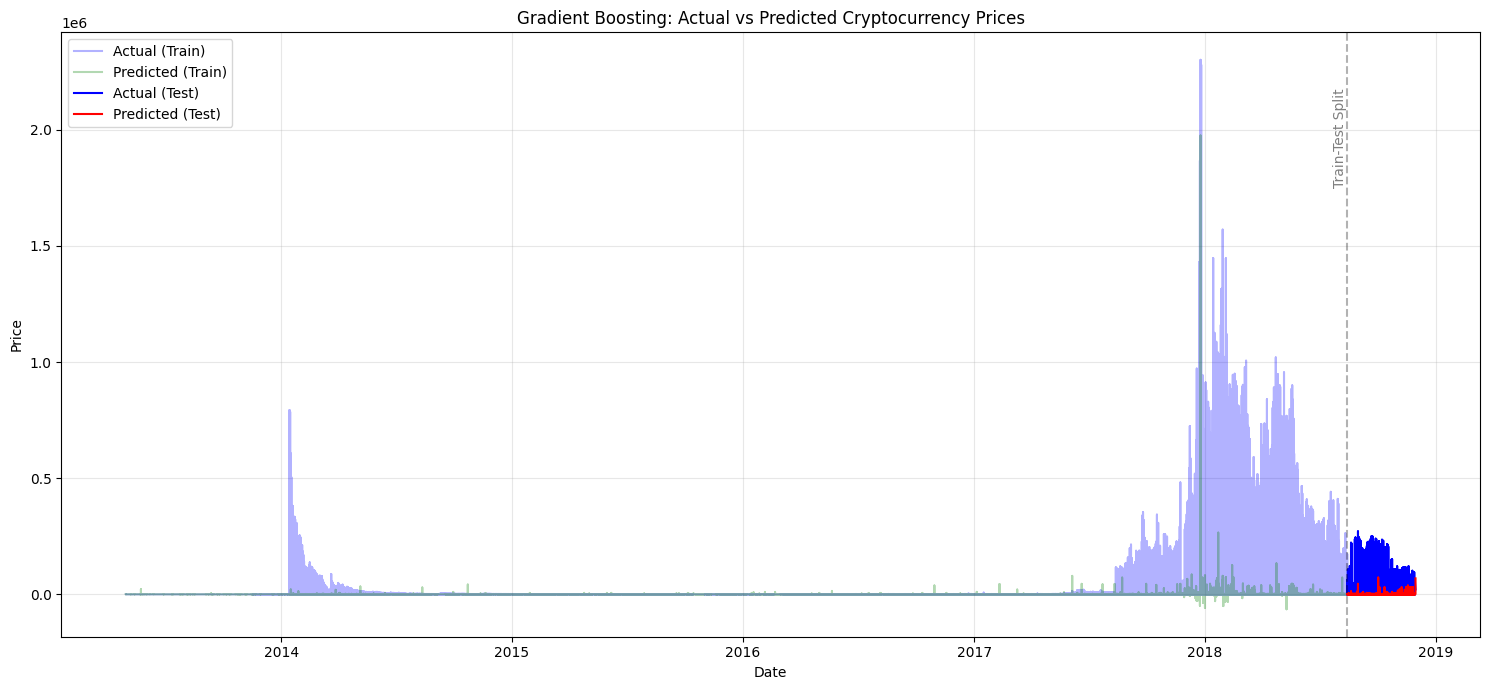

In [10]:
# Visualize actual vs predicted prices
plt.figure(figsize=(15, 7))

# Plot training data
plt.plot(dates_train, y_train, 'b-', label='Actual (Train)', alpha=0.3)
plt.plot(dates_train, train_preds, 'g-', label='Predicted (Train)', alpha=0.3)

# Plot test data
plt.plot(dates_test, y_test, 'b-', label='Actual (Test)')
plt.plot(dates_test, test_preds, 'r-', label='Predicted (Test)')

# Add vertical line to separate train and test sets
plt.axvline(x=dates_train.iloc[-1], color='k', linestyle='--', alpha=0.3)
plt.text(dates_train.iloc[-1], plt.ylim()[1]*0.9, 'Train-Test Split', 
         ha='right', va='top', rotation=90, alpha=0.5)

plt.title('Gradient Boosting: Actual vs Predicted Cryptocurrency Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Model and Metrics

Save the trained Gradient Boosting model and its performance metrics for later use in model comparison.

In [11]:
# Save the model and metadata
model_name = 'gradient_boosting'
model_filename = f'../models/{model_name}_model.pkl'

# Save the model
with open(model_filename, 'wb') as f:
    pickle.dump(gb_model, f)

# Save model metadata
model_metadata = {
    'name': 'Gradient Boosting',
    'features': features,
    'metrics': {
        'train': train_metrics,
        'test': test_metrics
    },
    'params': params,
    'feature_importance': {feature: importance for feature, importance in zip(features, feature_importance)},
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_filename = f'../models/{model_name}_metadata.pkl'
with open(metadata_filename, 'wb') as f:
    pickle.dump(model_metadata, f)

# Save predictions
predictions = {
    'train': {
        'dates': dates_train,
        'actual': y_train,
        'predicted': train_preds
    },
    'test': {
        'dates': dates_test,
        'actual': y_test,
        'predicted': test_preds
    }
}

predictions_filename = f'../models/{model_name}_predictions.pkl'
with open(predictions_filename, 'wb') as f:
    pickle.dump(predictions, f)

print(f"Model saved to: {model_filename}")
print(f"Metadata saved to: {metadata_filename}")
print(f"Predictions saved to: {predictions_filename}")

Model saved to: ../models/gradient_boosting_model.pkl
Metadata saved to: ../models/gradient_boosting_metadata.pkl
Predictions saved to: ../models/gradient_boosting_predictions.pkl
